In [196]:
from pathlib import Path
import xml.etree.ElementTree as ET
from collections import Counter

In [197]:
ANNOTATIONS_DIR = Path("EMO_CZ")
RECORDING_LIST_XML = Path("recordingList_EMO_CZ")

In [198]:
annotation_files = list(ANNOTATIONS_DIR.rglob("*.json.trans"))

# remove duplicates, based on the stem not the path
annotation_files = list({file.stem: file for file in annotation_files}.values())

print(f"Found {len(annotation_files)} annotation files.")

if annotation_files:
    print(f"First annotation file: {annotation_files[0]}")

Found 1166 annotation files.
First annotation file: EMO_CZ/2025_11_11_zaloha_prepisy_OK/3oaZs-hqHsw_002.json.trans


In [199]:
tree = ET.parse(RECORDING_LIST_XML)
root = tree.getroot()

rows = []
for rec in root.findall(".//recording"):
    title = (rec.findtext("title") or "").strip()
    annotator = (rec.findtext("annotator") or "").strip()
    status = (rec.findtext("status") or "").strip()
    annotator_status = (rec.findtext("annotator_status") or "").strip()
    rec_id = (rec.get("id") or "").strip()

    # skip empty <recording/> entries with no title
    if not title:
        continue

    rows.append(
        {
            "recording_id": rec_id,
            "title": title,
            "annotator": annotator or None,
            "status": status or None,
            "annotator_status": annotator_status or None,
        }
    )

title_to_row = {r["title"]: r for r in rows}

# 1) Get annotator for a specific recording title:
example_title = "clip_0091"
print(example_title, "=>", title_to_row.get(example_title))

# 2) List unique annotators (+ counts), excluding missing annotator IDs:
counts = Counter(r["annotator"] for r in rows if r["annotator"])
print("Unique annotators:", len(counts))
for annotator, n in counts.most_common():
    print(f"annotator {annotator}: {n} recordings")

# 3) Titles with missing annotator:
missing = [r["title"] for r in rows if not r["annotator"]]
print("Titles missing annotator:", len(missing))
print(missing[:20])

clip_0091 => {'recording_id': '261008', 'title': 'clip_0091', 'annotator': '21682', 'status': 'done', 'annotator_status': 'done'}
Unique annotators: 5
annotator 21677: 487 recordings
annotator 21682: 444 recordings
annotator 21678: 363 recordings
annotator 21702: 331 recordings
annotator 21712: 203 recordings
Titles missing annotator: 365
['5NsJZMbU9U0_002', '-gw-F_e_4bY_00010680_00036260', '-gw-F_e_4bY_00047125_00057625', '-gw-F_e_4bY_00091095_00108595', '-gw-F_e_4bY_00138075_00151649', '-gw-F_e_4bY_00193560_00208760', '-gw-F_e_4bY_00227765_00243015', '-gw-F_e_4bY_00276815_00285315', '-gw-F_e_4bY_00300000_00329640', '-gw-F_e_4bY_00365520_00394700', '-gw-F_e_4bY_00399560_00407685', '-gw-F_e_4bY_00419920_00445700', '-gw-F_e_4bY_00503775_00522775', '-gw-F_e_4bY_00565000_00594319', '-gw-F_e_4bY_00602495_00610995', '-gw-F_e_4bY_00662500_00682500', '-gw-F_e_4bY_00702245_00714495', '0TS9DRKuKVw_00098120_00107855', '0TS9DRKuKVw_00240195_00259695', '0TS9DRKuKVw_00263840_00290980']


In [200]:
import json
import pandas as pd

In [201]:
df = pd.DataFrame()

LABEL_TRANSLATE_MAP = {
    "Vzrušení (arousal)": "arousal",
    "Dominance": "dominance",
    "Pohlaví": "gender",
    "Tempo řeči": "speech_rate",
    "Valence": "valence",
    "Jemnost/Drsnost hlasu": "voice_quality",
    "Dozvuk (reverb)": "reverb",
    "Monotónnost/Melodičnost": "monotony_melody",
}

for file in annotation_files:
    df_row = {}
    with open(file, 'r', encoding='utf-8') as f:
        annotation_data = json.load(f)

    groups = annotation_data.get("groups", [])

    if not groups:
        continue

    for group in groups:
        df_row["audio"] = file.stem.replace(".json", "")
        df_row["start"] = float(group.get("start")) 
        df_row["end"] = float(group.get("end"))
        df_row["annotator"] = title_to_row.get(file.stem.replace(".json", ""), {}).get("annotator")
        for tag in group.get("tags"):
            label = tag.get("label")
            if label == "Emoce":
                group_emotions = set()
                leaf_emotions = set()
                for subcat in tag.get("subcategories"):
                    group_emotions.add(subcat["label"])
                    for emotion in subcat.get("subcategories", []):
                        leaf_emotions.add(emotion["label"])
                df_row["emotions"] = list(leaf_emotions)
                df_row["emotion_categories"] = list(group_emotions)
            else:
                try:
                    df_row[LABEL_TRANSLATE_MAP[label]] = tag.get("subcategories")[0]["label"].split(":")[1].strip()
                except TypeError:
                    df_row[LABEL_TRANSLATE_MAP[label]] = None
                    print("No subcategories found in tag:", tag)
                    continue

        df = pd.concat([df, pd.DataFrame([df_row])], ignore_index=True)

# filter out rows with no emotions
df = df[df["emotions"].map(lambda x: isinstance(x, list) and len(x) > 0)]
df = df.reset_index(drop=True)

print(f"Total annotated segments: {len(df)}")
print(f"Total time of anotated segments in hours: {(df['end'].sum() - df['start'].sum()) / 3600:.2f} hours")

print(df.head(n=10).to_markdown(tablefmt="grid"))

No subcategories found in tag: {'label': 'Dominance'}
No subcategories found in tag: {'label': 'Tempo řeči'}
Total annotated segments: 1427
Total time of anotated segments in hours: 4.81 hours
+----+-----------------+---------+-------+-------------+-----------------------------------------+------------------------------------------+----------+---------------+----------------------------+--------------------------------------+-------------+------------------------------+---------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------+
|    | audio           |   start |   end |   annotator | arousal                                 | dominance                                | gender   | speech_rate   | valence                    | voice_quality                        | reverb      | monotony_melody              | emotions                                                | e

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [203]:
df = df.dropna(subset=['emotions', 'arousal', 'valence'])

# Calculate duration in seconds
df['duration'] = df['end'] - df['start']

df = df.reset_index(drop=True)

# Basic sanity check
print(f"Shortest segment: {df['duration'].min():.2f}s")
print(f"Longest segment: {df['duration'].max():.2f}s")
print(f"Average segment: {df['duration'].mean():.2f}s")

df.head(4)

Shortest segment: 0.00s
Longest segment: 29.60s
Average segment: 11.84s


,audio,start,end,annotator,arousal,dominance,gender,speech_rate,valence,voice_quality,reverb,monotony_melody,emotions,emotion_categories,duration
0,3oaZs-hqHsw_002,0.4,26.7,21677,"Vzrušený (např. nadšený, mluví hlasitě)",Neutrální,Žena,Střední,Pozitivní (např. příjemný),Neutrální,Bez dozvuku,Neutrální,"[Frustrace, Zájem, Zamyšlení]","[Negativní emoce s vysokou energií, Kognitivní...",26.3
1,3oaZs-hqHsw_003,0.0,9.4,21677,Normální řeč (např. běžná konverzace),Neutrální,Žena,Střední,Pozitivní (např. příjemný),Neutrální,Bez dozvuku,Neutrální,"[Klid/Tranquilita, Zájem]","[Kognitivní stavy a procesy, Pozitivní emoce s...",9.4
2,3oaZs-hqHsw_004,0.3,12.7,21712,"Vzrušený (např. nadšený, mluví hlasitě)","Dominantní (např. asertivní, sebevědomý)",Muž,Střední,Pozitivní (např. příjemný),Mírně drsný (nějaká hrubost),Bez dozvuku,Melodická (příjemná variace),[Naděje/Nadšení/Optimismus],[Pozitivní emoce s vysokou energií],12.4
3,5NsJZMbU9U0_004,0.2,13.8,21677,Normální řeč (např. běžná konverzace),Neutrální,Muž,Střední,Pozitivní (např. příjemný),"Velmi jemný (melodický, uklidňující)",Bez dozvuku,Melodická (příjemná variace),"[Potěšení/Euforie, Spokojenost, Klid/Tranquilita]","[Pozitivní emoce s nízkou energií, Pozitivní e...",13.6


/tmp/ipykernel_13171/2359865227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.values, y=emotion_counts.index, palette='mako')


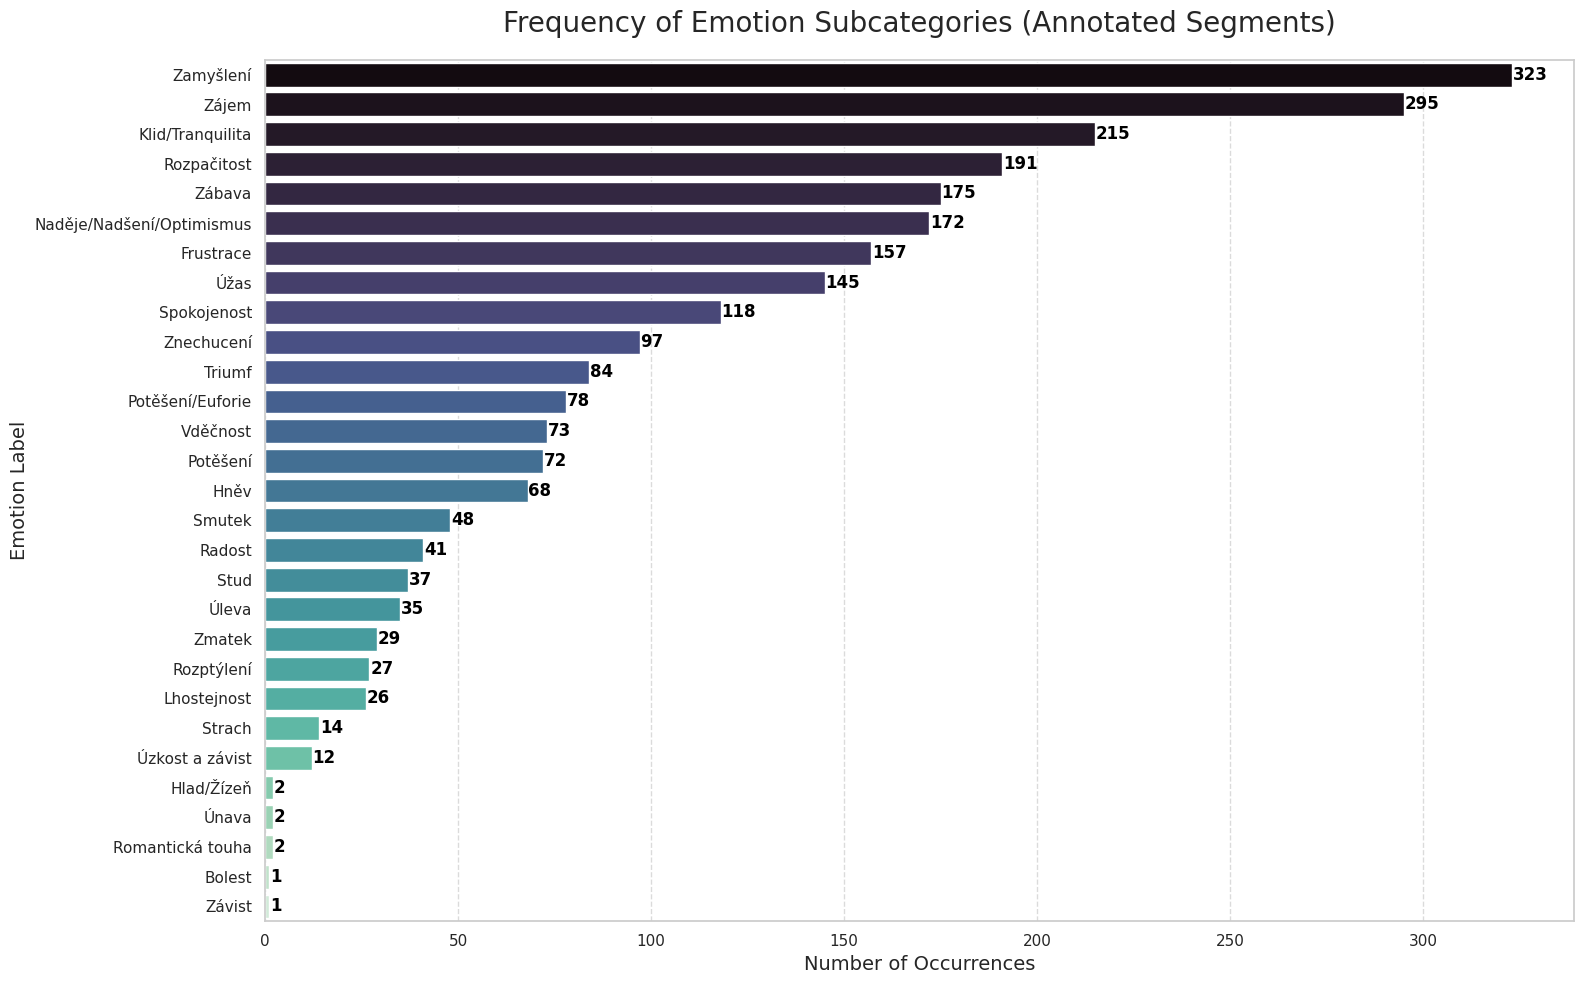

In [204]:
plt.figure(figsize=(16, 10)) # Extra wide and tall

# Explode and count
df_exploded = df.explode('emotions')
emotion_counts = df_exploded['emotions'].value_counts()

# Plot with specialized 'mako' palette for better contrast
sns.barplot(x=emotion_counts.values, y=emotion_counts.index, palette='mako')

plt.title('Frequency of Emotion Subcategories (Annotated Segments)', fontsize=20, pad=20)
plt.xlabel('Number of Occurrences', fontsize=14)
plt.ylabel('Emotion Label', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to the end of each bar for precision
for i, v in enumerate(emotion_counts.values):
    plt.text(v + 0.2, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

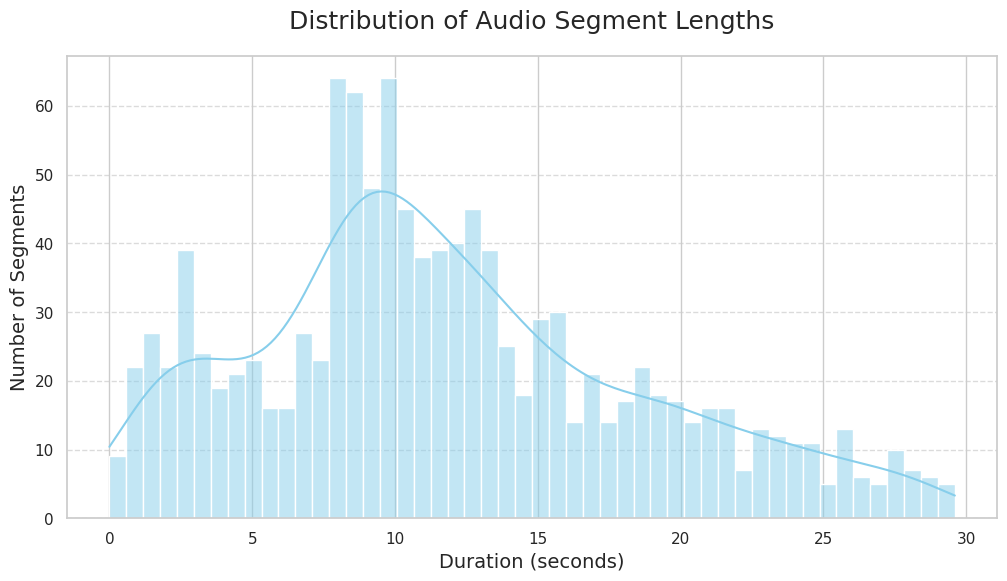

In [205]:
# Distribution of sample lengths
plt.figure(figsize=(12, 6))
sns.histplot(df['duration'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Audio Segment Lengths', fontsize=18, pad=20)
plt.xlabel('Duration (seconds)', fontsize=14)
plt.ylabel('Number of Segments', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_13171/4023275135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')


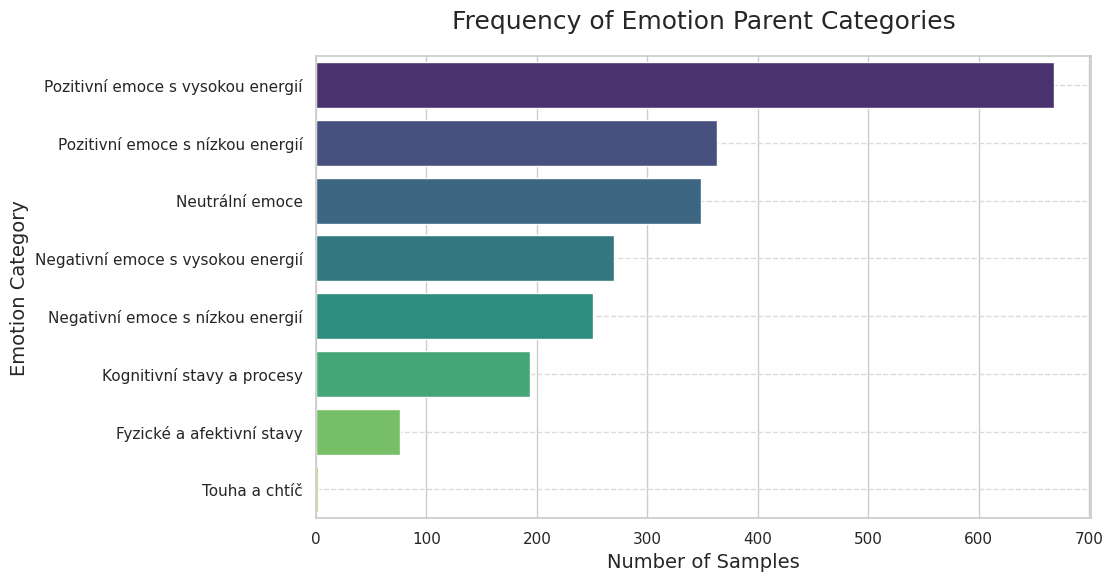

In [206]:
# distribution of emotion_categories
plt.figure(figsize=(10, 6))
df_exploded_cat = df.explode('emotion_categories')
category_counts = df_exploded_cat['emotion_categories'].value_counts()
sns.barplot(y=category_counts.index, x=category_counts.values, palette='viridis')
plt.title('Frequency of Emotion Parent Categories', fontsize=18, pad=20)
plt.ylabel('Emotion Category', fontsize=14)
plt.xlabel('Number of Samples', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

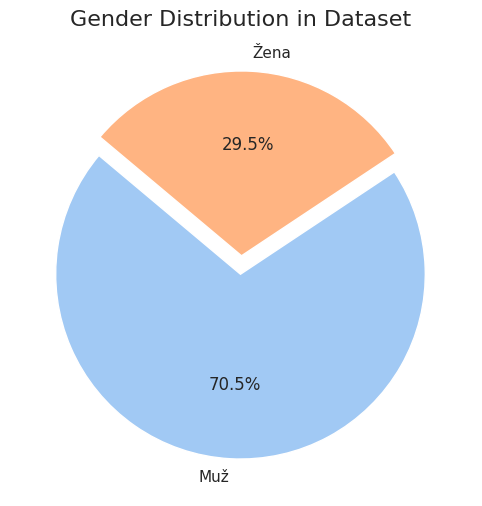

In [207]:
plt.figure(figsize=(10, 6))
gender_counts = df['gender'].value_counts(dropna=False)
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140, explode=[0.05]*len(gender_counts))
plt.title('Gender Distribution in Dataset', fontsize=16)
plt.show()

<Figure size 1400x800 with 0 Axes>

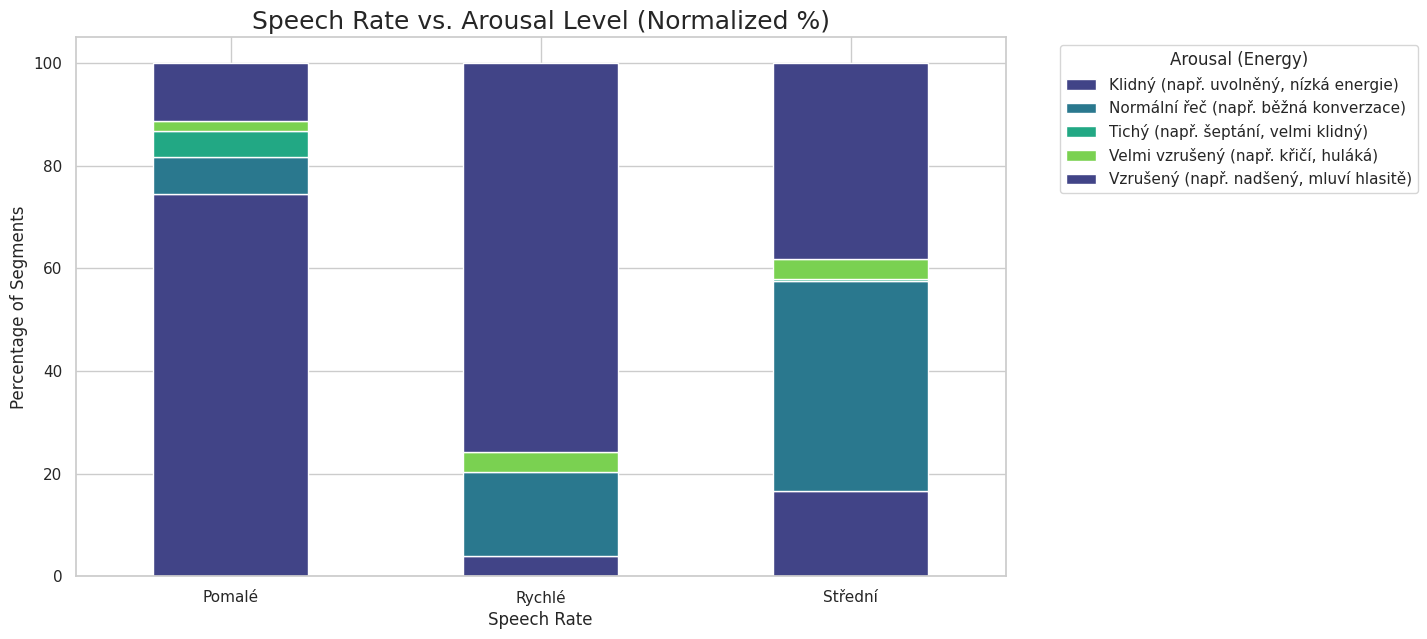

In [208]:
plt.figure(figsize=(14, 8))
rate_energy_pivot = pd.crosstab(df['speech_rate'], df['arousal'], normalize='index') * 100

rate_energy_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=sns.color_palette('viridis', 4))
plt.title('Speech Rate vs. Arousal Level (Normalized %)', fontsize=18)
plt.ylabel('Percentage of Segments')
plt.xlabel('Speech Rate')
plt.legend(title='Arousal (Energy)', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.show()

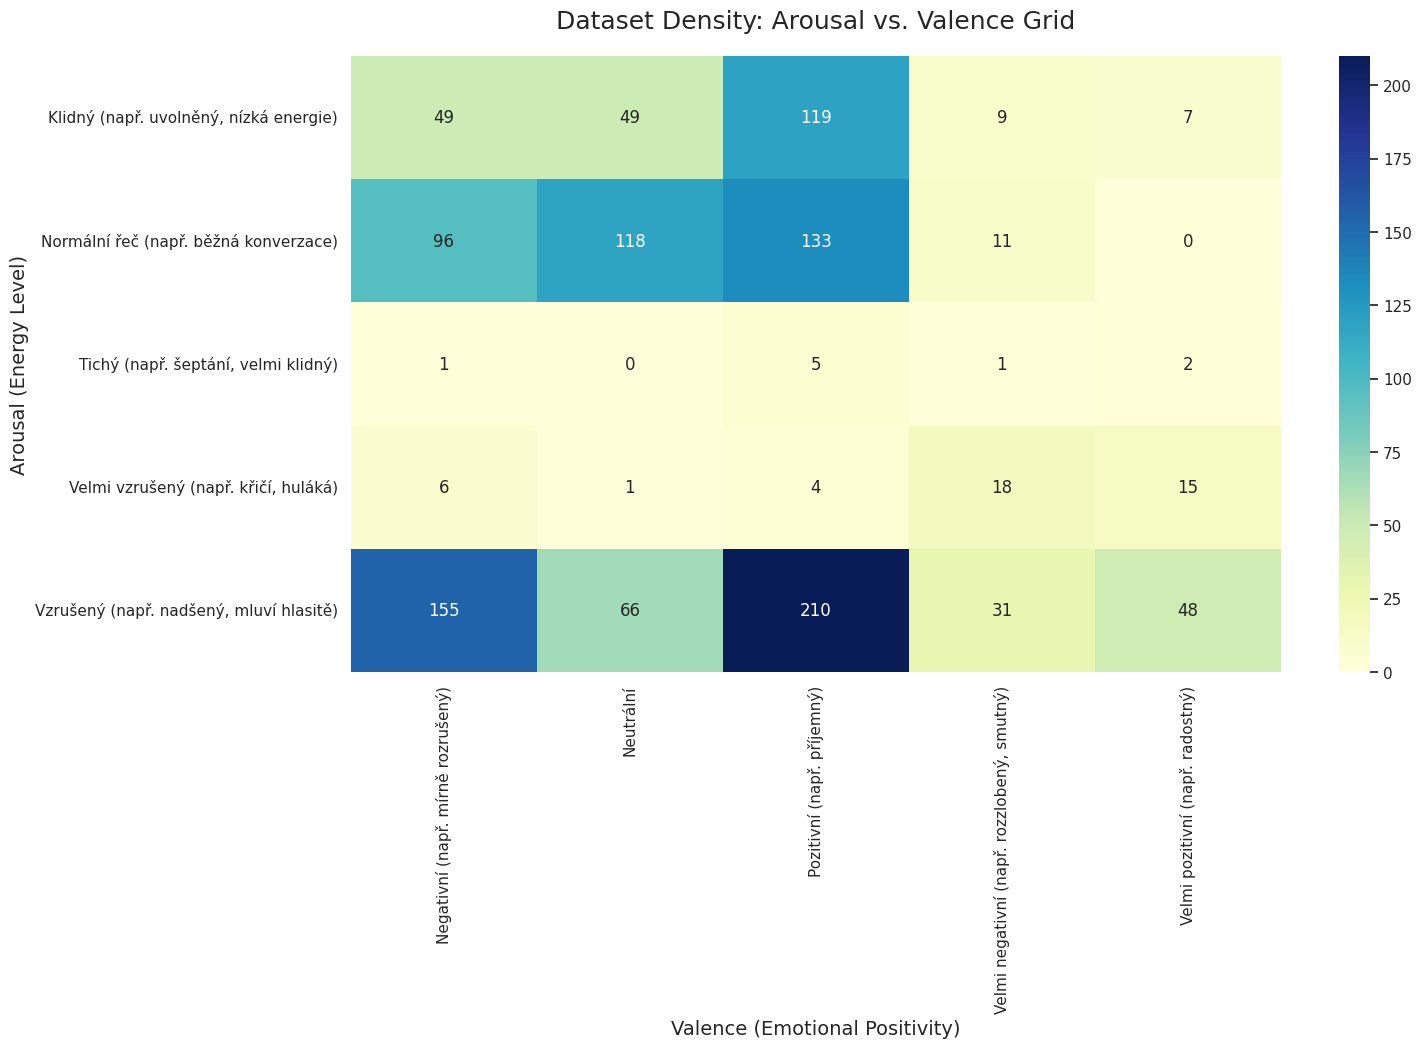

In [209]:
plt.figure(figsize=(15, 8))
# Grouping by Arousal and Valence to see the "heat" of your dataset
pivot_table = df.pivot_table(index='arousal', columns='valence', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Dataset Density: Arousal vs. Valence Grid', fontsize=18, pad=20)
plt.ylabel('Arousal (Energy Level)', fontsize=14)
plt.xlabel('Valence (Emotional Positivity)', fontsize=14)
plt.show()

/tmp/ipykernel_13171/2435551670.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exploded, x='duration', y='emotions', palette='viridis')


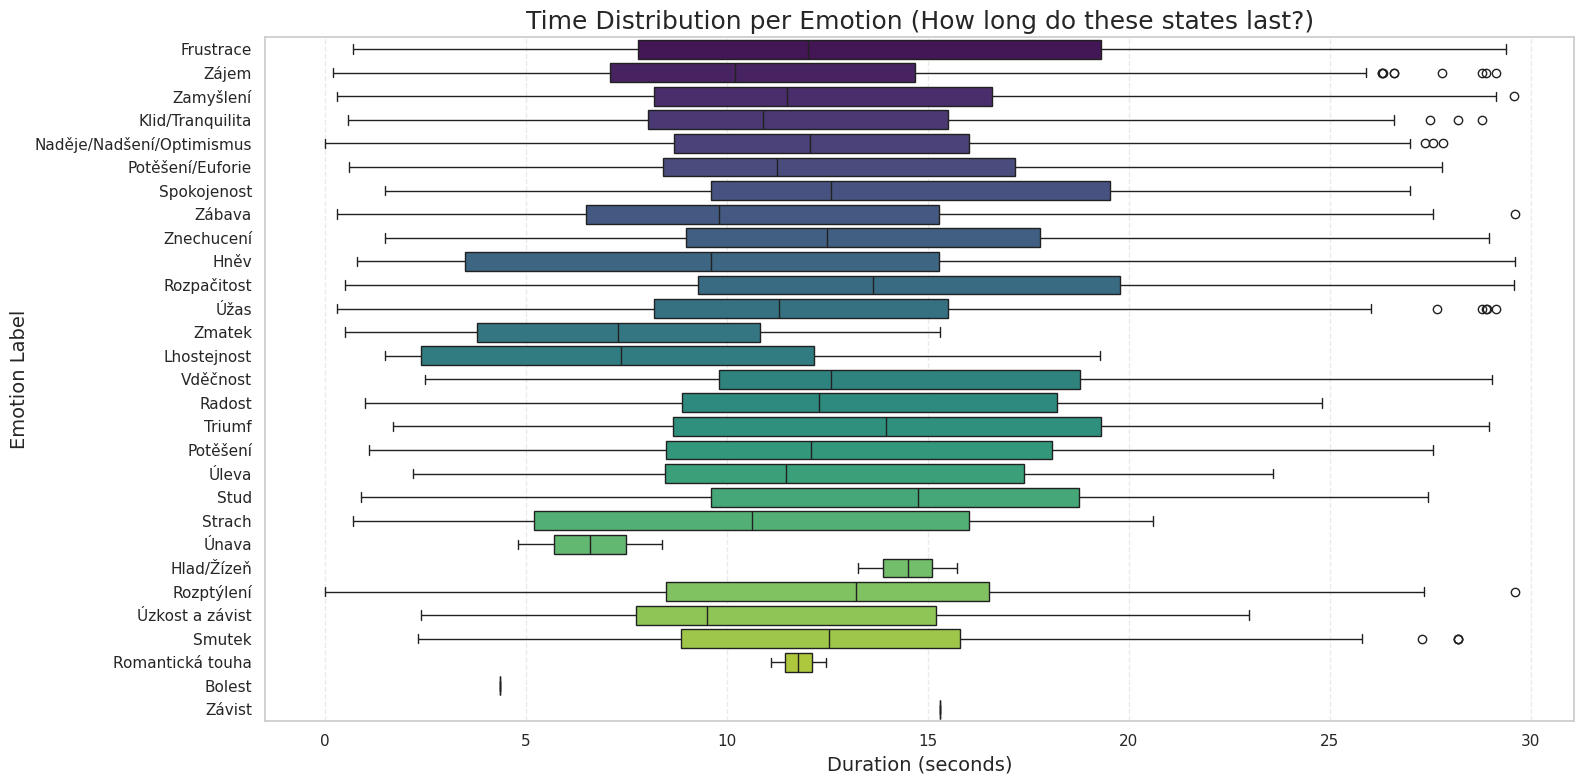

In [210]:
plt.figure(figsize=(16, 8))

# We use the exploded dataframe so we see the duration for every label occurrence
df_exploded = df.explode('emotions')

# Reset the index to remove duplicates (This fixes the ValueError)
df_exploded = df_exploded.reset_index(drop=True)

# Boxplot showing the distribution of time for each emotion
sns.boxplot(data=df_exploded, x='duration', y='emotions', palette='viridis')

plt.title('Time Distribution per Emotion (How long do these states last?)', fontsize=18)
plt.xlabel('Duration (seconds)', fontsize=14)
plt.ylabel('Emotion Label', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

<Figure size 1600x800 with 0 Axes>

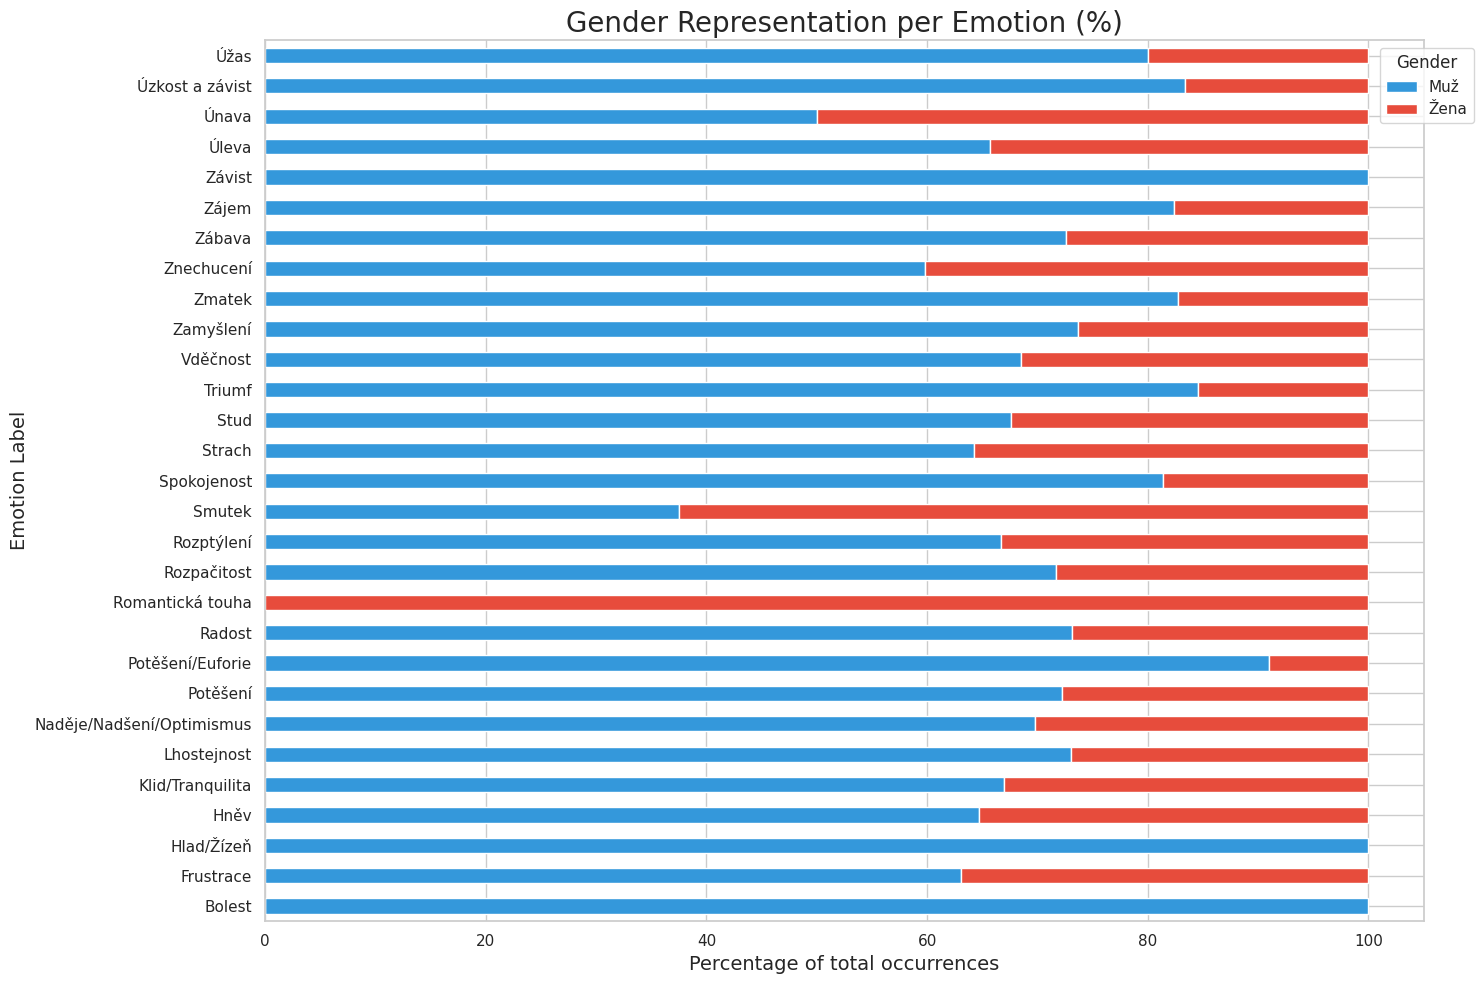

In [211]:
plt.figure(figsize=(16, 8))

# Create a cross-tabulation of emotions and gender
# We use the exploded DF so we count every instance of an emotion
gender_emo = pd.crosstab(df_exploded['emotions'], df_exploded['gender'])

# Normalize to see percentages (e.g., what % of 'Zájem' was spoken by women?)
gender_emo_pct = gender_emo.div(gender_emo.sum(1), axis=0) * 100

gender_emo_pct.plot(kind='barh', stacked=True, figsize=(15, 10), 
                    color=['#3498db', '#e74c3c', '#95a5a6'])

plt.title('Gender Representation per Emotion (%)', fontsize=20)
plt.xlabel('Percentage of total occurrences', fontsize=14)
plt.ylabel('Emotion Label', fontsize=14)
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

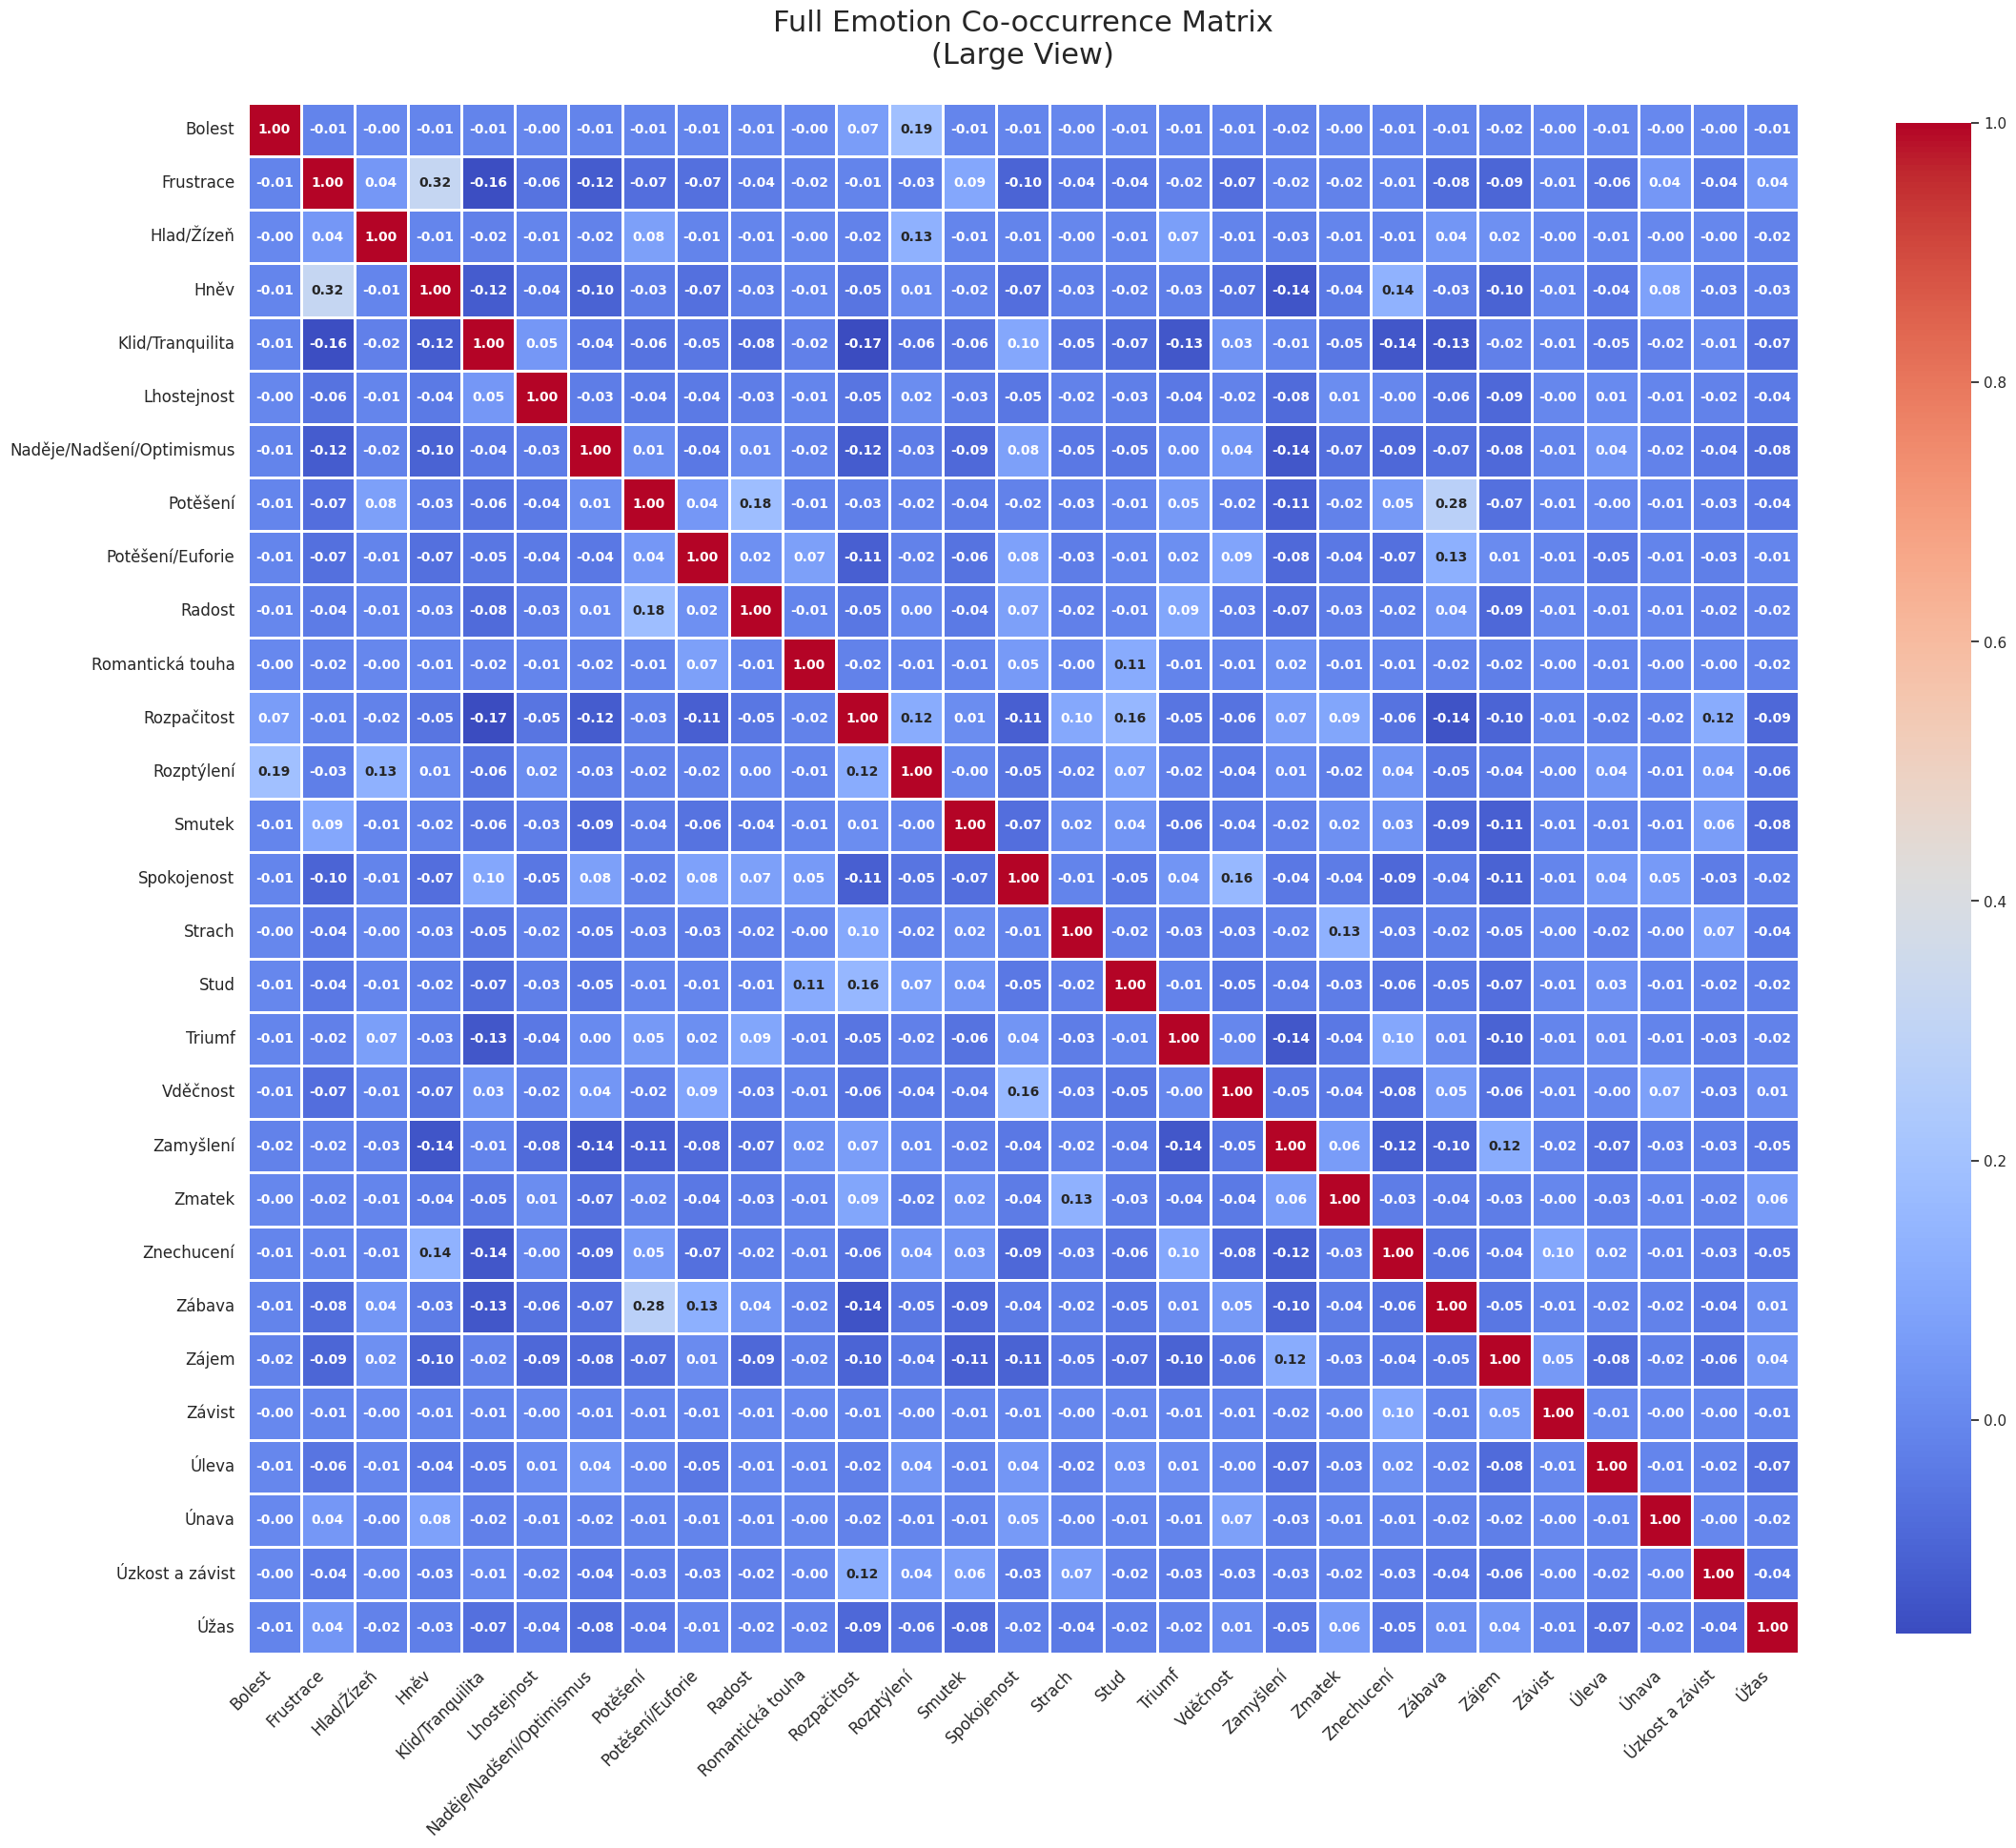

In [212]:
from sklearn.preprocessing import MultiLabelBinarizer

# This shows how often different "Emoce" subcategories appear together
mlb = MultiLabelBinarizer()
indicator_matrix = mlb.fit_transform(df['emotions'])
indicator_df = pd.DataFrame(indicator_matrix, columns=mlb.classes_)

if not indicator_df.empty and len(indicator_df.columns) > 1:
    # Scale the figure size based on the number of labels to keep squares large
    num_labels = len(indicator_df.columns)
    fig_size = max(12, num_labels * 0.8) 
    
    plt.figure(figsize=(fig_size, fig_size)) 
    
    # Calculate correlation
    corr = indicator_df.corr()
    
    # Plotting the full matrix
    sns.heatmap(
        corr, 
        annot=True,           # Show the numbers
        cmap='coolwarm',      # Blue (negative) to Red (positive)
        fmt=".2f",            # 2 decimal places
        linewidths=1,         # Thicker lines between squares
        square=True,          # Force cells to be square-shaped and large
        cbar_kws={"shrink": .7}, # Make the color bar a bit smaller
        annot_kws={"size": 10, "weight": "bold"} # Larger font for the numbers
    )
    
    plt.title('Full Emotion Co-occurrence Matrix\n(Large View)', fontsize=22, pad=30)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    
    plt.tight_layout()
    plt.show()

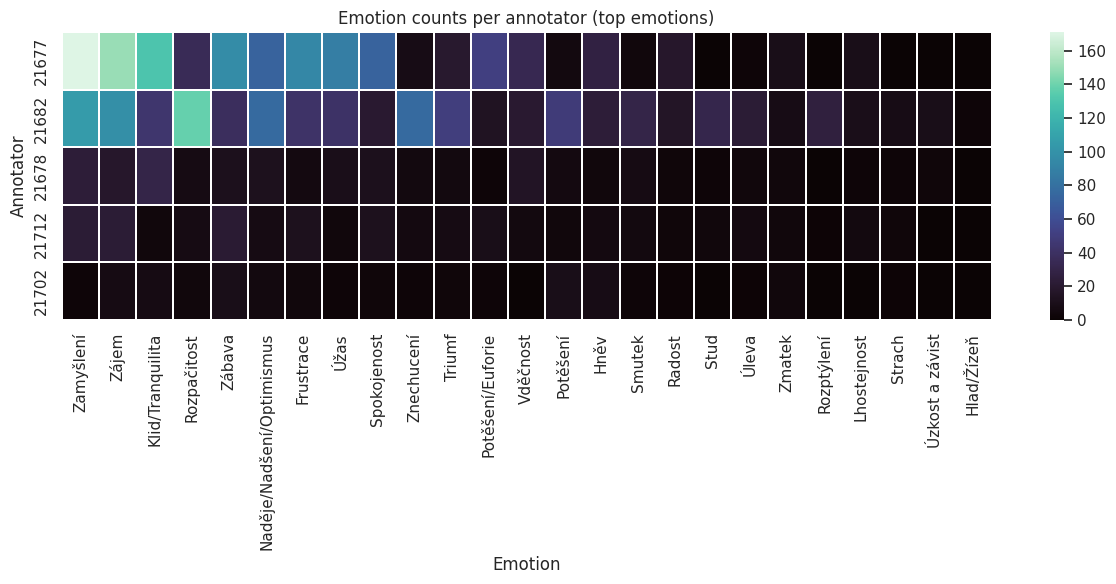

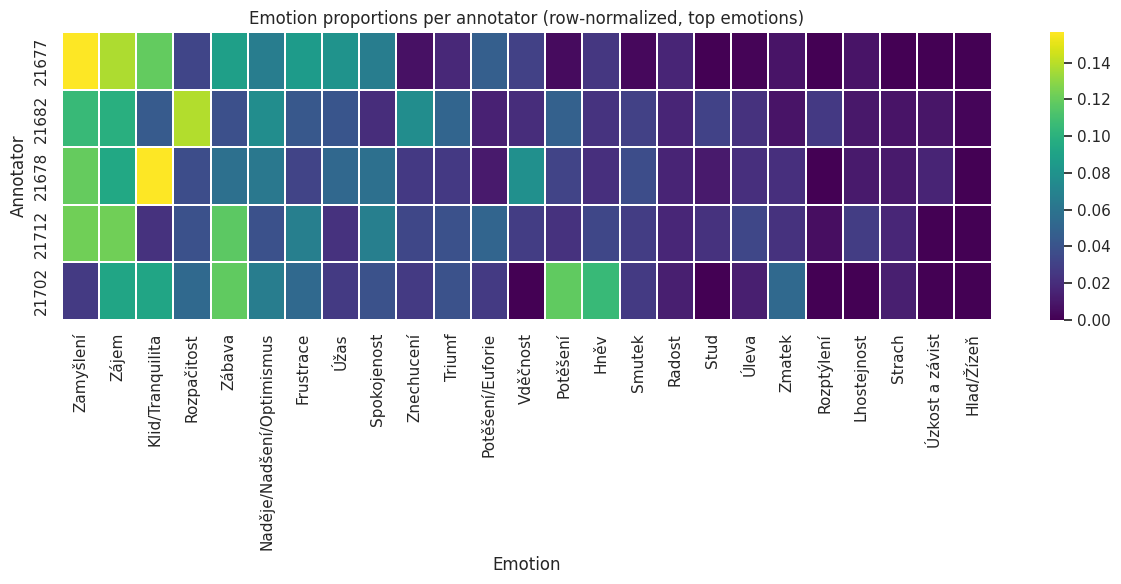

In [213]:
# Explode to 1 row per (segment, emotion) and keep only rows with annotator+emotion
df_ea = df.dropna(subset=["annotator", "emotions"]).explode("emotions")
df_ea = df_ea.dropna(subset=["emotions"])

# Count table: rows=annotator, cols=emotion
counts = pd.crosstab(df_ea["annotator"], df_ea["emotions"])

# keep only top-N emotions overall to make the plot readable
TOP_N = 25
top_emotions = counts.sum(axis=0).sort_values(ascending=False).head(TOP_N).index
counts_top = counts.loc[:, top_emotions]

# Order annotators by total annotations
counts_top = counts_top.loc[counts_top.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(max(10, 0.5 * counts_top.shape[1]), max(6, 0.4 * counts_top.shape[0])))
sns.heatmap(counts_top, cmap="mako", linewidths=0.25, linecolor="white")
plt.title("Emotion counts per annotator (top emotions)")
plt.xlabel("Emotion")
plt.ylabel("Annotator")
plt.tight_layout()
plt.show()

# Normalized (per-annotator proportions) heatmap to compare distributions, not volume
props_top = counts_top.div(counts_top.sum(axis=1).replace(0, pd.NA), axis=0)

plt.figure(figsize=(max(10, 0.5 * props_top.shape[1]), max(6, 0.4 * props_top.shape[0])))
sns.heatmap(props_top, cmap="viridis", linewidths=0.25, linecolor="white")
plt.title("Emotion proportions per annotator (row-normalized, top emotions)")
plt.xlabel("Emotion")
plt.ylabel("Annotator")
plt.tight_layout()
plt.show()

In [214]:
qc = {
    "rows_total": len(df),
    "rows_missing_annotator": int(df["annotator"].isna().sum()),
    "rows_missing_emotions": int(df["emotions"].isna().sum()),
    "rows_missing_arousal": int(df["arousal"].isna().sum()) if "arousal" in df else None,
    "rows_missing_valence": int(df["valence"].isna().sum()) if "valence" in df else None,
}
print(qc)

# durations
df["duration"] = df["end"] - df["start"]
print(df["duration"].describe(percentiles=[.01, .05, .5, .95, .99]))

# segment counts per audio (tail = outliers)
seg_per_audio = df.groupby("audio").size().sort_values(ascending=False)
print("segments per audio (top 20):")
print(seg_per_audio.head(20))

{'rows_total': 1154, 'rows_missing_annotator': 0, 'rows_missing_emotions': 0, 'rows_missing_arousal': 0, 'rows_missing_valence': 0}
count    1154.000000
mean       11.836482
std         6.763291
min         0.000000
1%          0.700000
5%          1.777514
50%        10.813969
95%        24.735000
99%        28.215027
max        29.600000
Name: duration, dtype: float64
segments per audio (top 20):
audio
TH_RwDJsO0OE5M_110                    6
KG_BeDLTZvIXmY_frame_157495_173995    5
RwDJsO0OE5M_052                       4
JZ_RwDJsO0OE5M_110                    4
rcDdVBmz6hQ_059                       4
KG_eQtT9wlcXeM_frame_456375_485625    4
rcDdVBmz6hQ_019                       4
rcDdVBmz6hQ_013                       4
KG_-BoDEvTUn_o_frame_590135_600000    4
RwDJsO0OE5M_110                       4
BeDLTZvIXmY_frame_157495_173995       4
rcDdVBmz6hQ_004                       4
KG_rcDdVBmz6hQ_013                    4
xt4Rj8ZukYM_frame_1901640_1912265     4
-BoDEvTUn_o_frame_590135_600000 

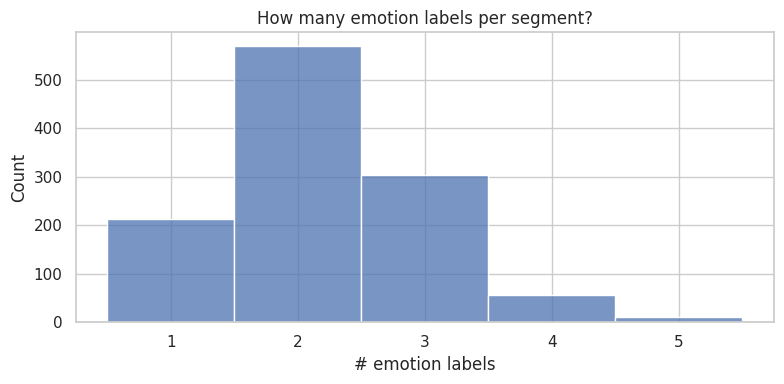

In [215]:
df_ml = df.dropna(subset=["emotions"]).copy()
df_ml["n_emotions"] = df_ml["emotions"].map(lambda x: len(x) if isinstance(x, list) else 0)

plt.figure(figsize=(8,4))
sns.histplot(df_ml["n_emotions"], bins=range(1, df_ml["n_emotions"].max()+2), discrete=True)
plt.title("How many emotion labels per segment?")
plt.xlabel("# emotion labels")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from pathlib import Path
from pydub import AudioSegment

# --- CONFIGURATION ---
OUTPUT_DIR = Path("prepared_dataset")
SEGMENTS_DIR = OUTPUT_DIR / "segments"

# Ensure directories exist
SEGMENTS_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
manifest = []

for idx, row in df.iterrows():
    source_file = next(ANNOTATIONS_DIR.rglob(f"*{row['audio']}.wav"), None)
    if source_file is None or not source_file.exists():
        continue

    try:
        new_file_name = f"seg_{idx:04d}.wav"
        target_path = SEGMENTS_DIR / new_file_name
        
        audio = AudioSegment.from_file(source_file)
        segment = audio[row['start']*1000 : row['end']*1000]
        segment = segment.set_frame_rate(16000).set_channels(1)
        segment.export(target_path, format="wav")
        
        manifest.append({
            "audio": new_file_name,
            "emotions": row['emotions'],
            "emotion_categories": row['emotion_categories'],
            "duration": row['duration'],
        })
    except Exception as e:
        print(f"Error processing {idx}: {e}")

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(OUTPUT_DIR / "train_manifest.csv", index=False)